In [1]:
import pandas as pd
data = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\BERTopic\BBCnews_cleaned.csv').drop(columns='Unnamed: 0')
# 你把 list 存成 .csv 之後，pandas.read_csv 會把它當成 字串，不會還原回原本的 list。
# 所以
import ast
data['Tokens'] = data['Tokens'].apply(ast.literal_eval)
import numpy as np
np.random.seed(42)

In [2]:
df = data[data['category'].isin(['tech', 'sport'])].reset_index(drop=True)
df.to_csv('sport_tech_bbcnews.csv')

In [18]:
df.head()

,category,filename,title,content,Tokens,cleaned_content
0,sport,001.txt,Claxton hunting first major medal,British hurdler Sarah Claxton is confident sh...,"[british, hurdler, sarah, claxton, confident, ...",british hurdler sarah claxton confident win ma...
1,sport,002.txt,O'Sullivan could run in Worlds,Sonia O'Sullivan has indicated that she would...,"[sonia, osullivan, indicate, like, participate...",sonia osullivan indicate like participate mont...
2,sport,003.txt,Greene sets sights on world title,Maurice Greene aims to wipe out the pain of l...,"[maurice, greene, aim, wipe, pain, lose, olymp...",maurice greene aim wipe pain lose olympic titl...
3,sport,004.txt,IAAF launches fight against drugs,The IAAF - athletics' world governing body - ...,"[iaaf, athletic, world, govern, body, meet, an...",iaaf athletic world govern body meet antidope ...
4,sport,005.txt,"Dibaba breaks 5,000m world record",Ethiopia's Tirunesh Dibaba set a new world re...,"[ethiopias, tirunesh, dibaba, set, new, world,...",ethiopias tirunesh dibaba set new world record...


In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 使用 cleaned_content 作為輸入，建立 TF 與 TF-IDF 矩陣
tf_vectorizer = CountVectorizer()
tfidf_vectorizer = TfidfVectorizer()

# 建立 document-term matrices
tf_matrix = tf_vectorizer.fit_transform(df['cleaned_content'])
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_content'])

# 轉成 DataFrame 格式以便檢視
tf_df = pd.DataFrame(tf_matrix.toarray(), columns=tf_vectorizer.get_feature_names_out())
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())


In [5]:
# tf_df.to_csv("sport_tech_tf.txt", index=False, sep='\t')
# tfidf_df.to_csv("sport_tech_tfidf.txt", index=False, sep='\t')

---
---

### baseline LDA

In [6]:
from gensim import corpora
from gensim.models import LdaModel

# 建立詞典與 BOW（Bag-of-Words）語料
dictionary = corpora.Dictionary(df["Tokens"])
corpus = [dictionary.doc2bow(tokens) for tokens in df["Tokens"]]

# 訓練 baseline LDA 模型（假設先設定為 2 個主題）
lda_baseline = LdaModel(corpus=corpus, id2word=dictionary, num_topics=2, random_state=42, passes=10, iterations=100)

In [7]:
print("\n每個主題的前 20 詞：")
for k in range(2):
    top_words = lda_baseline.show_topic(k, topn=20)
    print(f"Topic {k+1}: {[w for w, _ in top_words]}")


每個主題的前 20 詞：
Topic 1: ['game', 'win', 'play', 'player', 'year', 'time', 'england', 'good', 'come', 'new', 'world', 'use', 'team', 'think', 'people', 'match', 'like', 'look', 'club', 'try']
Topic 2: ['people', 'use', 'mobile', 'technology', 'phone', 'year', 'service', 'new', 'mr', 'music', 'digital', 'world', 'computer', 'user', 'time', 'firm', 'player', 'network', 'company', 'work']


In [8]:
doc_topics = lda_baseline.get_document_topics(corpus, minimum_probability=0)
topic_distributions = pd.DataFrame([[prob for _, prob in doc] for doc in doc_topics])
topic_distributions.columns = [f"Topic_{i+1}" for i in range(2)]
topic_distributions['BBC_Label'] = df['category'].values
topic_distributions

,Topic_1,Topic_2,BBC_Label
0,0.237693,0.762307,sport
1,0.680270,0.319730,sport
2,0.947006,0.052994,sport
3,0.611180,0.388820,sport
4,0.096912,0.903087,sport
...,...,...,...
907,0.250797,0.749203,tech
908,0.477820,0.522180,tech
909,0.132266,0.867734,tech
910,0.824138,0.175862,tech


In [9]:
mean_distribution_per_label = topic_distributions.groupby('BBC_Label').mean()
print(mean_distribution_per_label.T) 

BBC_Label     sport      tech
Topic_1    0.901543  0.235902
Topic_2    0.098457  0.764098


In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
true_label = le.fit_transform(df['category'])

# 你的 LDA topic 分布（N x K matrix）
lda_probs = topic_distributions.iloc[:, :2].values

# ground truth label to one-hot (vec-y)
N = len(true_label)
K = len(le.classes_)

Y_onehot = np.zeros((N, K))
Y_onehot[np.arange(N), true_label] = 1

from sklearn.metrics.pairwise import cosine_similarity

consistency_scores = []

for y_true, y_hat in zip(Y_onehot, lda_probs):
    score = cosine_similarity([y_true], [y_hat])[0][0]
    consistency_scores.append(score)

print("Average Consistency (y vs y_hat):", round(np.mean(consistency_scores), 4))

category_centroids = {}

for idx, label in enumerate(le.classes_):
    mask = (true_label == idx)
    centroid = lda_probs[mask].mean(axis=0)
    category_centroids[label] = centroid

centroid_matrix = np.vstack(list(category_centroids.values()))

# 類別中心兩兩 cosine 相似度
similarity_matrix = cosine_similarity(centroid_matrix)

# 類別中心兩兩 L2 距離
distance_matrix = cdist(centroid_matrix, centroid_matrix, metric='euclidean')

centroid_df = pd.DataFrame(similarity_matrix, index=le.classes_, columns=le.classes_)
print("\nCategory Center Cosine Similarity:")
print(centroid_df)

distance_df = pd.DataFrame(distance_matrix, index=le.classes_, columns=le.classes_)
print("\nCategory Center L2 Distance:")
print(distance_df)


Average Consistency (y vs y_hat): 0.8885

Category Center Cosine Similarity:
          sport      tech
sport  1.000000  0.396984
tech   0.396984  1.000000

Category Center L2 Distance:
          sport      tech
sport  0.000000  0.941358
tech   0.941358  0.000000


In [11]:
from sklearn.metrics import f1_score

# 1. 原始標籤：BBC 類別轉換為 0/1（sport = 0, tech = 1）
true_labels = topic_distributions["BBC_Label"].map({"sport": 1, "tech": 2}).values

# 2. LDA 預測：主題機率較高的那一類
# 假設你命名為 Topic_1 = sport, Topic_2 = tech
pred_labels = topic_distributions[["Topic_1", "Topic_2"]].idxmax(axis=1).map({"Topic_1": 1, "Topic_2": 2}).values

# 3. 計算 F1-score（針對 tech 類別，label=1）
f1 = f1_score(true_labels, pred_labels, average='binary', pos_label=1)

print(f"F1-score: {f1:.4f}")


F1-score: 0.8755


In [20]:
# 0.8755

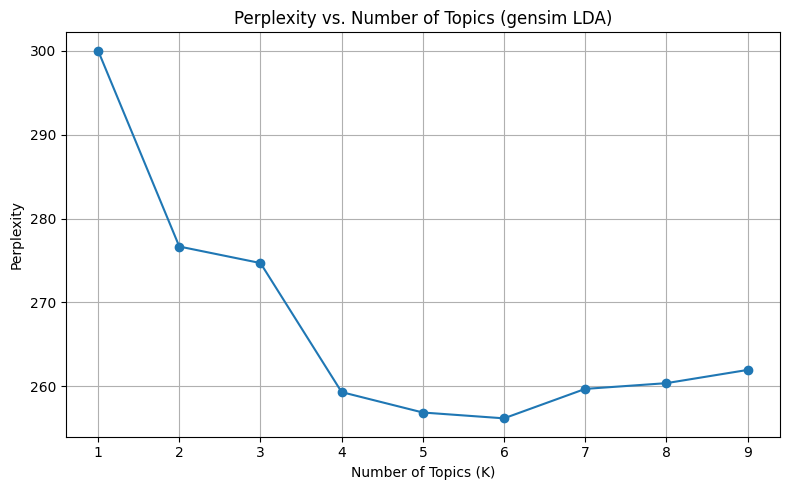

,Topic數,Perplexity
0,1,300.026431
1,2,276.674340
2,3,274.702672
3,4,259.313120
4,5,256.880150
5,6,256.184539
6,7,259.695902
7,8,260.380191
8,9,261.956329


In [15]:
import matplotlib.pyplot as plt

# 計算不同主題數下的 perplexity（使用 log perplexity 近似）
perplexities = []
topic_nums = list(range(1, 10))

for k in topic_nums:
    lda_baseline = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k, random_state=42, passes=10, iterations=100)
    perplexity = np.exp2(-lda_baseline.log_perplexity(corpus))  # 轉為 perplexity
    perplexities.append(perplexity)

# 畫圖
plt.figure(figsize=(8, 5))
plt.plot(topic_nums, perplexities, marker='o')
plt.title("Perplexity vs. Number of Topics (gensim LDA)")
plt.xlabel("Number of Topics (K)")
plt.ylabel("Perplexity")
plt.grid(True)
plt.tight_layout()
plt.show()

df_result = pd.DataFrame({
    "Topic數": topic_nums,
    "Perplexity": perplexities
})
df_result

---
---
### Label LDA, delete the shared tokens

In [49]:
from gensim.models import LdaModel
from gensim import corpora
import numpy as np
# 建立詞典與 BOW（Bag-of-Words）語料
dictionary = corpora.Dictionary(df["Tokens"])
corpus = [dictionary.doc2bow(tokens) for tokens in df["Tokens"]]

# 為了模擬 Labeled LDA，我們先建立一個 token → topic label 的映射
# 這裡將所有在 tech 文件中出現的詞設為 topic 0，sport 文件中的設為 topic 1

# 取得兩類文件的 token
tech_tokens = df[df['category'] == 'tech']['Tokens'].explode()
sport_tokens = df[df['category'] == 'sport']['Tokens'].explode()

# 初始化 η（eta）矩陣
num_topics = 2
vocab_size = len(dictionary)

# 重新取得 tech 與 sport 類別的 token
tech_tokens_set = set(tech_tokens)
sport_tokens_set = set(sport_tokens)

# 找出兩類都出現過的共享詞
shared_tokens = tech_tokens_set & sport_tokens_set

# 建立新的 token → topic label 映射，只包含非共享詞
token_to_topic = {}
for token in tech_tokens_set - shared_tokens:
    token_to_topic[token] = 0
for token in sport_tokens_set - shared_tokens:
    token_to_topic[token] = 1

# 重新建立 eta 矩陣，非共享詞才賦予高權重
eta = np.full((num_topics, vocab_size), 0.01)
for word, word_id in dictionary.token2id.items():
    if word in token_to_topic:
        topic = token_to_topic[word]
        eta[topic, word_id] = 1.0

# 訓練新的 Label LDA 模型
lda_label = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=2,
    eta=eta,
    random_state=42,
    passes=10,
    iterations=100
)

print("\n每個主題的前 20 詞：")
for k in range(2):
    top_words = lda_label.show_topic(k, topn=20)
    print(f"Topic {k+1}: {[w for w, _ in top_words]}")



每個主題的前 20 詞：
Topic 1: ['people', 'use', 'game', 'technology', 'new', 'mr', 'year', 'service', 'user', 'phone', 'computer', 'firm', 'mobile', 'software', 'work', 'company', 'time', 'net', 'system', 'way']
Topic 2: ['win', 'game', 'play', 'player', 'year', 'good', 'england', 'time', 'world', 'come', 'match', 'second', 'team', 'new', 'think', 'club', 'cup', 'champion', 'coach', 'set']


In [50]:
doc_topics = lda_label.get_document_topics(corpus, minimum_probability=0)
topic_distributions = pd.DataFrame([[prob for _, prob in doc] for doc in doc_topics])
topic_distributions.columns = [f"Topic_{i+1}" for i in range(2)]
topic_distributions['BBC_Label'] = df['category'].values
topic_distributions

,Topic_1,Topic_2,BBC_Label
0,0.006240,0.993760,sport
1,0.008703,0.991297,sport
2,0.003730,0.996270,sport
3,0.071381,0.928619,sport
4,0.007868,0.992132,sport
...,...,...,...
907,0.996901,0.003099,tech
908,0.996749,0.003251,tech
909,0.998496,0.001504,tech
910,0.996618,0.003382,tech


In [53]:
mean_distribution_per_label = topic_distributions.groupby('BBC_Label').mean()
print(mean_distribution_per_label.T) 

BBC_Label     sport      tech
Topic_1    0.031989  0.979282
Topic_2    0.968011  0.020718


In [72]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
true_label = le.fit_transform(df['category'])

# 你的 LDA topic 分布（N x K matrix）
lda_probs = topic_distributions[["Topic_2", "Topic_1"]].values

# ground truth label to one-hot (vec-y)
N = len(true_label)
K = len(le.classes_)

Y_onehot = np.zeros((N, K))
Y_onehot[np.arange(N), true_label] = 1

from sklearn.metrics.pairwise import cosine_similarity
consistency_scores = []

for y_true, y_hat in zip(Y_onehot, lda_probs):
    score = cosine_similarity([y_true], [y_hat])[0][0]
    consistency_scores.append(score)

print("Average Consistency (y vs y_hat):", round(np.mean(consistency_scores), 4))

category_centroids = {}

for idx, label in enumerate(le.classes_):
    mask = (true_label == idx)
    centroid = lda_probs[mask].mean(axis=0)
    category_centroids[label] = centroid

centroid_matrix = np.vstack(list(category_centroids.values()))

# 類別中心兩兩 cosine 相似度
similarity_matrix = cosine_similarity(centroid_matrix)

# 類別中心兩兩 L2 距離
distance_matrix = cdist(centroid_matrix, centroid_matrix, metric='euclidean')

centroid_df = pd.DataFrame(similarity_matrix, index=le.classes_, columns=le.classes_)
print("\nCategory Center Cosine Similarity:")
print(centroid_df)

distance_df = pd.DataFrame(distance_matrix, index=le.classes_, columns=le.classes_)
print("\nCategory Center L2 Distance:")
print(distance_df)


Average Consistency (y vs y_hat): 0.996

Category Center Cosine Similarity:
          sport      tech
sport  1.000000  0.054161
tech   0.054161  1.000000

Category Center L2 Distance:
          sport      tech
sport  0.000000  1.339675
tech   1.339675  0.000000


In [73]:
from sklearn.metrics import confusion_matrix
confusion_matrix(true_labels, pred_labels)

array([[401,   0],
       [  2, 509]], dtype=int64)

In [74]:
from sklearn.metrics import f1_score

# 1. 原始標籤：BBC 類別轉換為 0/1（sport = 0, tech = 1）
true_labels = topic_distributions["BBC_Label"].map({"sport": 1, "tech": 0}).values

# 2. LDA 預測：主題機率較高的那一類
# 假設你命名為 Topic_1 = sport, Topic_2 = tech
pred_labels = topic_distributions[["Topic_1", "Topic_2"]].idxmax(axis=1).map({"Topic_1": 0, "Topic_2": 1}).values

# 3. 計算 F1-score（針對 tech 類別，label=1）
f1 = f1_score(true_labels, pred_labels, average='binary', pos_label=1)

print(f"F1-score (tech as positive class): {f1:.4f}")


F1-score (tech as positive class): 0.9980


In [ ]:
# 0.998

---
---
### tf top-1000

In [83]:
from collections import Counter

# 統計所有 token 頻率
token_counter = Counter([token for tokens in df['Tokens'] for token in tokens])

# 選擇出現次數前 top_k 的詞
top_k = 1000
top_tokens = set([token for token, _ in token_counter.most_common(top_k)])

# 過濾 token list
df['token_topk'] = df['Tokens'].apply(lambda tokens: [t for t in tokens if t in top_tokens])


In [84]:
from sklearn.feature_extraction.text import CountVectorizer

# 用空格 join token_top1000 當輸入
joined_docs = df['token_topk'].apply(lambda tokens: ' '.join(tokens))
vectorizer_top1000 = CountVectorizer()
tf_top1000 = vectorizer_top1000.fit_transform(joined_docs)

# 轉為 DataFrame 並輸出為 .txt
tf_top1000_df = pd.DataFrame(tf_top1000.toarray(), columns=vectorizer_top1000.get_feature_names_out())
# tf_top1000_df.to_csv('tf_top1000.txt', sep='\t', index=False)
# tf_top1000_df.to_csv('tf_top1000.csv', index=False)


In [85]:
from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import pandas as pd
import numpy as np

# === 1. 建立字典與語料 ===
dictionary = Dictionary(df['Tokens'])
corpus = [dictionary.doc2bow(tokens) for tokens in df['Tokens']]

# === 2. 建立 TF 矩陣（P x N） ===
tf_df = pd.DataFrame(0, index=dictionary.token2id.keys(), columns=range(len(df)))
for doc_id, tokens in enumerate(df['Tokens']):
    for token in tokens:
        if token in tf_df.index:
            tf_df.loc[token, doc_id] += 1

tf_matrix = tf_df.values  # P × N
V = len(dictionary)

# === 3. 讀取 token 分群（GAP） ===
token_df = pd.read_csv(r'C:\Users\USER\Documents\GitHub\psychic-spoon\tf_top1000的token分配主題.csv')
token_df = token_df[token_df['token'].isin(dictionary.token2id)].reset_index(drop=True)

# 重新建立 token_index（對應 tf_df 的 index）
token_index_map = {token: idx for idx, token in enumerate(tf_df.index)}
token_df['token_idx'] = token_df['token'].map(token_index_map)

# === 4. 建立 token_vectors：每個 token 在 topic 空間的語意向量 ===
K = 2  # 預設 topic 數
lda_baseline = LdaModel(corpus=corpus, id2word=dictionary, num_topics=K, random_state=42)
lda_probs = np.array([[prob for _, prob in lda_baseline.get_document_topics(doc, minimum_probability=0)] for doc in corpus])

token_vectors = tf_matrix @ lda_probs  # P × K
token_sums = tf_matrix.sum(axis=1, keepdims=True)
token_sums[token_sums == 0] = 1e-10
token_vectors = token_vectors / token_sums
token_vectors = normalize(token_vectors, axis=1)

# === 5. 建 GAP topic → LDA topic mapping ===
gap_topics = sorted(token_df['topic'].unique())
gap_to_lda = {gap_k: lda_k for lda_k, gap_k in enumerate(gap_topics)}

# === 6. GAP cluster centers ===
cluster_centers = []
for gap_k in gap_topics:
    cluster_token_idx = token_df[token_df['topic'] == gap_k]['token_idx']
    cluster_vecs = token_vectors[cluster_token_idx]

    if len(cluster_vecs) == 0:
        center = np.random.rand(K)
    else:
        center = cluster_vecs.mean(axis=0)

    center /= (np.linalg.norm(center) + 1e-10)
    cluster_centers.append(center)

cluster_centers = np.vstack(cluster_centers)

# === 7. 建立 η 矩陣（K × V） ===
eta_rows = []

for i in range(V):
    vec = token_vectors[i]
    similarities = cosine_similarity([vec], cluster_centers)[0]
    temp = 10
    similarities = np.clip(similarities, 1e-6, 1.0)
    soft_weights = np.exp(temp * similarities)
    soft_weights /= soft_weights.sum()
    eta_rows.append(soft_weights)

eta = np.array(eta_rows).T  # K × V

# === 8. 建立 LDA 模型 ===
lda_top1000 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=K,
    eta=eta,
    random_state=42,
    iterations=100,
    passes=10,
    alpha=0.1
)

# === 9. 顯示主題結果 ===
print("\n每個主題的前 20 詞：")
for k in range(K):
    top_words = lda_top1000.show_topic(k, topn=20)
    print(f"Topic {k+1}: {[w for w, _ in top_words]}")

# === 10. 顯示 η 中有套用 GAP 的 token 數量 ===
covered_words = [w for w in token_df['token'] if w in dictionary.token2id]
print(f"\n你的 GAP 分群中共 {len(token_df)} 個 token，其中 {len(covered_words)} 個成功對應到 dictionary。")



每個主題的前 20 詞：
Topic 1: ['game', 'win', 'play', 'player', 'year', 'time', 'good', 'england', 'world', 'come', 'new', 'use', 'team', 'think', 'match', 'people', 'like', 'look', 'try', 'club']
Topic 2: ['people', 'use', 'mobile', 'technology', 'phone', 'service', 'year', 'new', 'mr', 'music', 'digital', 'user', 'world', 'computer', 'firm', 'network', 'time', 'player', 'million', 'work']

你的 GAP 分群中共 1000 個 token，其中 1000 個成功對應到 dictionary。


In [86]:
doc_topics = lda_top1000.get_document_topics(corpus, minimum_probability=0)
topic_distributions = pd.DataFrame([[prob for _, prob in doc] for doc in doc_topics])
topic_distributions.columns = [f"Topic_{i+1}" for i in range(2)]
topic_distributions['BBC_Label'] = df['category'].values
topic_distributions

,Topic_1,Topic_2,BBC_Label
0,0.433346,0.566654,sport
1,0.998631,0.001369,sport
2,0.999359,0.000641,sport
3,0.998810,0.001190,sport
4,0.196333,0.803667,sport
...,...,...,...
907,0.116307,0.883693,tech
908,0.463465,0.536535,tech
909,0.105698,0.894302,tech
910,0.822417,0.177583,tech


In [87]:
mean_distribution_per_label = topic_distributions.groupby('BBC_Label').mean()
print(mean_distribution_per_label.T) 

BBC_Label     sport     tech
Topic_1    0.955242  0.19881
Topic_2    0.044758  0.80119


In [88]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
true_label = le.fit_transform(df['category'])

# 你的 LDA topic 分布（N x K matrix）
lda_probs = topic_distributions.iloc[:, :2].values

# ground truth label to one-hot (vec-y)
N = len(true_label)
K = len(le.classes_)

Y_onehot = np.zeros((N, K))
Y_onehot[np.arange(N), true_label] = 1

from sklearn.metrics.pairwise import cosine_similarity

consistency_scores = []

for y_true, y_hat in zip(Y_onehot, lda_probs):
    score = cosine_similarity([y_true], [y_hat])[0][0]
    consistency_scores.append(score)

print("Average Consistency (y vs y_hat):", round(np.mean(consistency_scores), 4))

category_centroids = {}

for idx, label in enumerate(le.classes_):
    mask = (true_label == idx)
    centroid = lda_probs[mask].mean(axis=0)
    category_centroids[label] = centroid

centroid_matrix = np.vstack(list(category_centroids.values()))

# 類別中心兩兩 cosine 相似度
similarity_matrix = cosine_similarity(centroid_matrix)

# 類別中心兩兩 L2 距離
distance_matrix = cdist(centroid_matrix, centroid_matrix, metric='euclidean')

centroid_df = pd.DataFrame(similarity_matrix, index=le.classes_, columns=le.classes_)
print("\nCategory Center Cosine Similarity:")
print(centroid_df)

distance_df = pd.DataFrame(distance_matrix, index=le.classes_, columns=le.classes_)
print("\nCategory Center L2 Distance:")
print(distance_df)


Average Consistency (y vs y_hat): 0.9224

Category Center Cosine Similarity:
          sport      tech
sport  1.000000  0.286003
tech   0.286003  1.000000

Category Center L2 Distance:
          sport      tech
sport  0.000000  1.069755
tech   1.069755  0.000000


In [89]:
from sklearn.metrics import f1_score

# 1. 原始標籤：BBC 類別轉換為 0/1（sport = 0, tech = 1）
true_labels = topic_distributions["BBC_Label"].map({"sport": 1, "tech": 2}).values

# 2. LDA 預測：主題機率較高的那一類
# 假設你命名為 Topic_1 = sport, Topic_2 = tech
pred_labels = topic_distributions[["Topic_1", "Topic_2"]].idxmax(axis=1).map({"Topic_1": 1, "Topic_2": 2}).values

# 3. 計算 F1-score（針對 tech 類別，label=1）
f1 = f1_score(true_labels, pred_labels, average='binary', pos_label=1)

print(f"F1-score (tech as positive class): {f1:.4f}")


F1-score (tech as positive class): 0.9073


In [9]:
# 0.9073

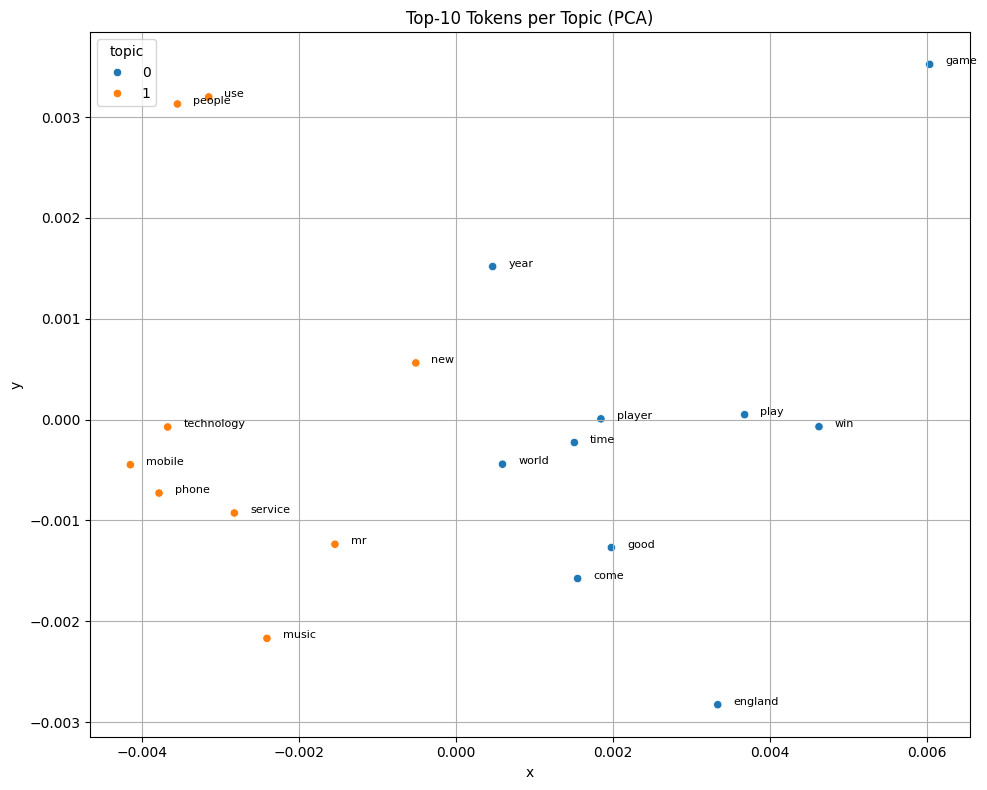

In [106]:
import numpy as np

# 取得所有詞
id2token = {v: k for k, v in dictionary.token2id.items()}
V = len(dictionary)

# 建立 token × topic 矩陣（用 get_term_topics）
token_vectors = np.zeros((V, lda_top1000.num_topics))
for token_id in range(V):
    topic_probs = lda_top1000.get_term_topics(token_id, minimum_probability=0)
    for topic_id, prob in topic_probs:
        token_vectors[token_id, topic_id] = prob

import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 每個 topic 抓前 10 個詞
top_words = []
for topic_id in range(lda_top1000.num_topics):
    for word, prob in lda_top1000.show_topic(topic_id, topn=10):
        top_words.append({'token': word, 'topic': topic_id})

top_df = pd.DataFrame(top_words).drop_duplicates('token')

# 2. 對應詞向量
token_id_map = dictionary.token2id
token_idx = [token_id_map[t] for t in top_df['token'] if t in token_id_map]
token_vecs = token_vectors[token_idx]

# 3. PCA 降維
pca = PCA(n_components=2)
coords = pca.fit_transform(token_vecs)
top_df['x'] = coords[:, 0]
top_df['y'] = coords[:, 1]

# 4. 視覺化
plt.figure(figsize=(10, 8))
ax = sns.scatterplot(data=top_df, x='x', y='y', hue='topic', palette='tab10')

# 加入文字標籤在正確的圖層上（用 ax）
for _, row in top_df.iterrows():
    ax.text(row['x'] + 0.0002, row['y'], row['token'], fontsize=8)

plt.title('Top-10 Tokens per Topic (PCA)')
plt.grid(True)
plt.tight_layout()
plt.show()


---
---

### 單獨tech

In [20]:
tech = data[data['category'].isin(['tech'])].reset_index(drop=True)
# tech.to_csv('tech_bbcnews.csv')
tech.head()

,category,filename,title,content,Tokens,cleaned_content
0,tech,001.txt,Ink helps drive democracy in Asia,"The Kyrgyz Republic, a small, mountainous sta...","[kyrgyz, republic, small, mountainous, state, ...",kyrgyz republic small mountainous state soviet...
1,tech,002.txt,China net cafe culture crackdown,"Chinese authorities closed 12,575 net cafes i...","[chinese, authority, close, net, cafe, closing...",chinese authority close net cafe closing month...
2,tech,003.txt,Microsoft seeking spyware trojan,Microsoft is investigating a trojan program t...,"[microsoft, investigate, trojan, program, atte...",microsoft investigate trojan program attempt s...
3,tech,004.txt,Digital guru floats sub-$100 PC,"Nicholas Negroponte, chairman and founder of ...","[nicholas, negroponte, chairman, founder, mit,...",nicholas negroponte chairman founder mit mediu...
4,tech,005.txt,Technology gets the creative bug,The hi-tech and the arts worlds have for some...,"[hitech, art, world, time, dance, offer, creat...",hitech art world time dance offer creative tec...


In [21]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 使用 cleaned_content 作為輸入，建立 TF 與 TF-IDF 矩陣
tf_vectorizer = CountVectorizer()
tfidf_vectorizer = TfidfVectorizer()

# 建立 document-term matrices
tf_tech_matrix = tf_vectorizer.fit_transform(tech['cleaned_content'])
tfidf_tech_matrix = tfidf_vectorizer.fit_transform(tech['cleaned_content'])

# 轉成 DataFrame 格式以便檢視
tf_tech = pd.DataFrame(tf_tech_matrix.toarray(), columns=tf_vectorizer.get_feature_names_out())
tfidf_tech = pd.DataFrame(tfidf_tech_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
# tf_tech.to_csv("tech_tf.txt", index=False, sep='\t')


In [ ]:
from collections import Counter

# 統計所有 token 頻率
token_counter = Counter([token for tokens in tech['Tokens'] for token in tokens])

# 選擇出現次數前 top_k 的詞
top_k = 1000
top_tokens = set([token for token, _ in token_counter.most_common(top_k)])

# 過濾 token list
tech['token_topk'] = tech['Tokens'].apply(lambda tokens: [t for t in tokens if t in top_tokens])

from sklearn.feature_extraction.text import CountVectorizer

# 用空格 join token_tech1000 當輸入
joined_docs = tech['token_topk'].apply(lambda tokens: ' '.join(tokens))
vectorizer_tech1000 = CountVectorizer()
tf_tech1000 = vectorizer_tech1000.fit_transform(joined_docs)

# 轉為 DataFrame 並輸出為 .txt
tf_tech1000_df = pd.DataFrame(tf_tech1000.toarray(), columns=vectorizer_tech1000.get_feature_names_out())
# tf_tech1000_df.to_csv('tech_tf1000.txt', sep='\t', index=False)

In [22]:
from gensim import corpora
from gensim.models import LdaModel

# 建立詞典與 BOW（Bag-of-Words）語料
dictionary_tech = corpora.Dictionary(tech["Tokens"])
corpus_tech = [dictionary_tech.doc2bow(tokens) for tokens in tech["Tokens"]]

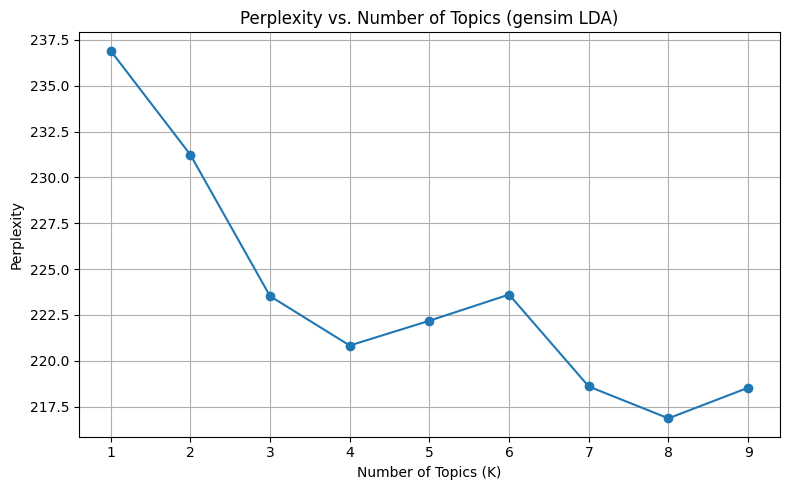

,Topic數,Perplexity
0,1,300.026431
1,2,276.674340
2,3,274.702672
3,4,259.313120
4,5,256.880150
5,6,256.184539
6,7,259.695902
7,8,260.380191
8,9,261.956329


In [23]:
import matplotlib.pyplot as plt

# 計算不同主題數下的 perplexity（使用 log perplexity 近似）
perplexities_tech = []
topic_nums = list(range(1, 10))

for k in topic_nums:
    lda_tech = LdaModel(corpus=corpus_tech, id2word=dictionary_tech, num_topics=k, random_state=42, passes=10, iterations=100)
    perplexity = np.exp2(-lda_tech.log_perplexity(corpus_tech))  # 轉為 perplexity
    perplexities_tech.append(perplexity)

# 畫圖
plt.figure(figsize=(8, 5))
plt.plot(topic_nums, perplexities_tech, marker='o')
plt.title("Perplexity vs. Number of Topics (gensim LDA)")
plt.xlabel("Number of Topics (K)")
plt.ylabel("Perplexity")
plt.grid(True)
plt.tight_layout()
plt.show()

df_result = pd.DataFrame({
    "Topic數": topic_nums,
    "Perplexity": perplexities
})
df_result

In [24]:
lda_tech = LdaModel(corpus=corpus_tech, id2word=dictionary_tech, num_topics=8, random_state=42, passes=10, iterations=100)

print("\n每個主題的前 20 詞：")
for k in range(8):
    top_words = lda_tech.show_topic(k, topn=20)
    print(f"Topic {k+1}: {[w for w, _ in top_words]}")


每個主題的前 20 詞：
Topic 1: ['phone', 'people', 'mobile', 'use', 'message', 'service', 'email', 'number', 'user', 'firm', 'net', 'year', 'mr', 'send', 'new', 'camera', 'spam', 'uk', 'consumer', 'customer']
Topic 2: ['use', 'software', 'microsoft', 'program', 'computer', 'user', 'security', 'people', 'release', 'firm', 'company', 'window', 'new', 'pc', 'version', 'chip', 'site', 'year', 'run', 'browser']
Topic 3: ['game', 'year', 'time', 'play', 'release', 'title', 'like', 'new', 'online', 'hour', 'computer', 'use', 'way', 'mr', 'world', 'pc', 'player', 'halo', 'people', 'sale']
Topic 4: ['game', 'technology', 'mobile', 'mr', 'play', 'console', 'new', 'nintendo', 'dvd', 'sony', 'video', 'film', 'people', 'time', 'gaming', 'company', 'phone', 'player', 'year', 'use']
Topic 5: ['site', 'people', 'use', 'virus', 'world', 'new', 'work', 'net', 'software', 'email', 'mr', 'firm', 'website', 'web', 'message', 'computer', 'user', 'law', 'service', 'radio']
Topic 6: ['use', 'computer', 'people', 'tec